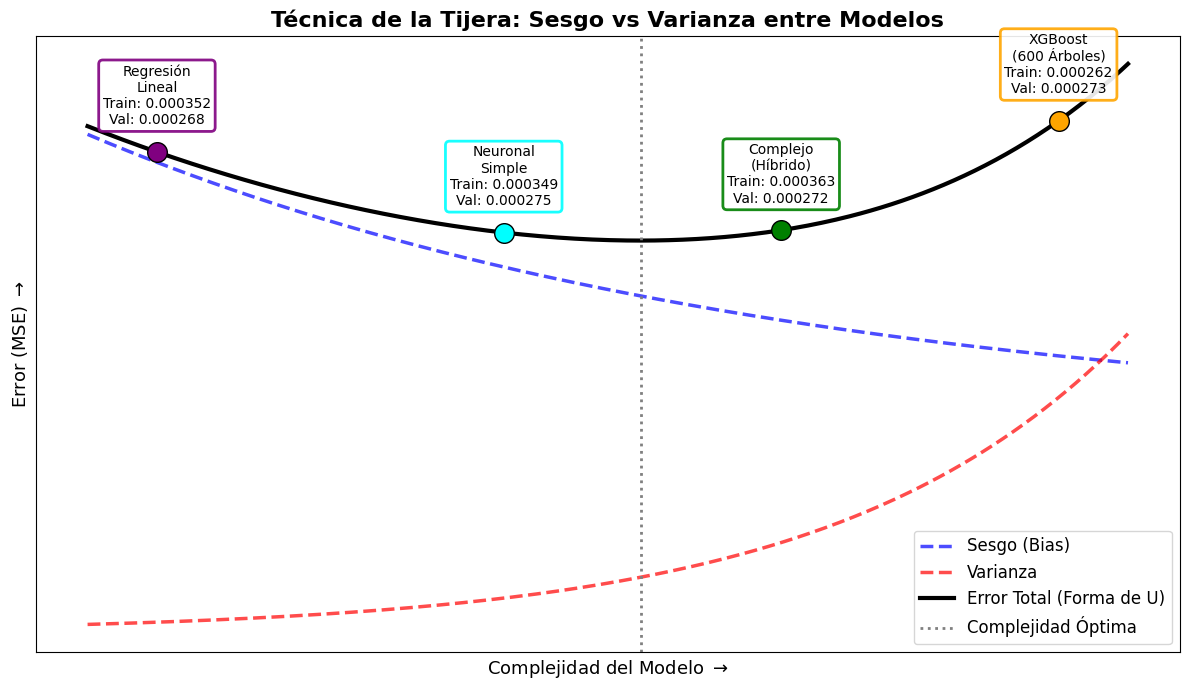

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el eje X continuo (Complejidad conceptual del Modelo)
x_smooth = np.linspace(1, 4, 300)

# 2. Definir curvas teóricas (esquemáticas) para ilustrar Bias, Varianza y Error Total
# Bias: Decrece según aumenta la complejidad
bias_curve = 0.000360 * np.exp(-0.5 * (x_smooth - 1)) + 0.000250
# Varianza: Crece exponencialmente al llegar a excesos de complejidad
variance_curve = 0.000010 * np.exp(1.2 * (x_smooth - 1))
# Error Total Teórico = Bias + Varianza
total_error_curve = bias_curve + variance_curve

# 3. Ubicar empíricamente nuestros modelos en este eje 'teórico' de complejidad
x_models = np.array([1.2, 2.2, 3.0, 3.8])
model_names = ['Regresión\nLineal', 'Neuronal\nSimple', 'Complejo\n(Híbrido)', 'XGBoost\n(600 Árboles)']

# MSE Real de Train y Validación extraído de nuestras anteriores pruebas
val_mse_real = np.array([0.000268, 0.000275, 0.000272, 0.000273])
train_mse_real = np.array([0.000352, 0.000349, 0.000363, 0.000262])

fig, ax = plt.subplots(figsize=(12, 7))

# Curvas teóricas de la receta (Técnica de la tijera)
ax.plot(x_smooth, bias_curve, 'b--', linewidth=2.5, alpha=0.7, label='Sesgo (Bias)')
ax.plot(x_smooth, variance_curve, 'r--', linewidth=2.5, alpha=0.7, label='Varianza')
ax.plot(x_smooth, total_error_curve, 'k-', linewidth=3, label='Error Total (Forma de U)')

# Anotar los modelos en sus posiciones estimadas de la U
colors = ['purple', 'cyan', 'green', 'orange']
for i in range(len(x_models)):
    y_pos = total_error_curve[np.abs(x_smooth - x_models[i]).argmin()]
    ax.scatter(x_models[i], y_pos, color=colors[i], s=200, zorder=5, edgecolors='black')

    texto_resumen = f"{model_names[i]}\nTrain: {train_mse_real[i]:.6f}\nVal: {val_mse_real[i]:.6f}"
    ax.annotate(texto_resumen, (x_models[i], y_pos), textcoords="offset points", xytext=(0,20), ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))

# Añadir línea vertical de Complejidad Óptima
optimum_x = x_smooth[np.argmin(total_error_curve)]
ax.axvline(x=optimum_x, color='gray', linestyle=':', linewidth=2, label='Complejidad Óptima')

# Estética
ax.set_title('Técnica de la Tijera: Sesgo vs Varianza entre Modelos', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Complejidad del Modelo $\rightarrow$', fontsize=13)
ax.set_ylabel(r'Error (MSE) $\rightarrow$', fontsize=13)
ax.set_xticks([])
ax.set_yticks([])  # Ocultamos ticks para mantener el concepto puramente explicativo
ax.grid(False)

# Leyenda movida a la parte inferior derecha
ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()




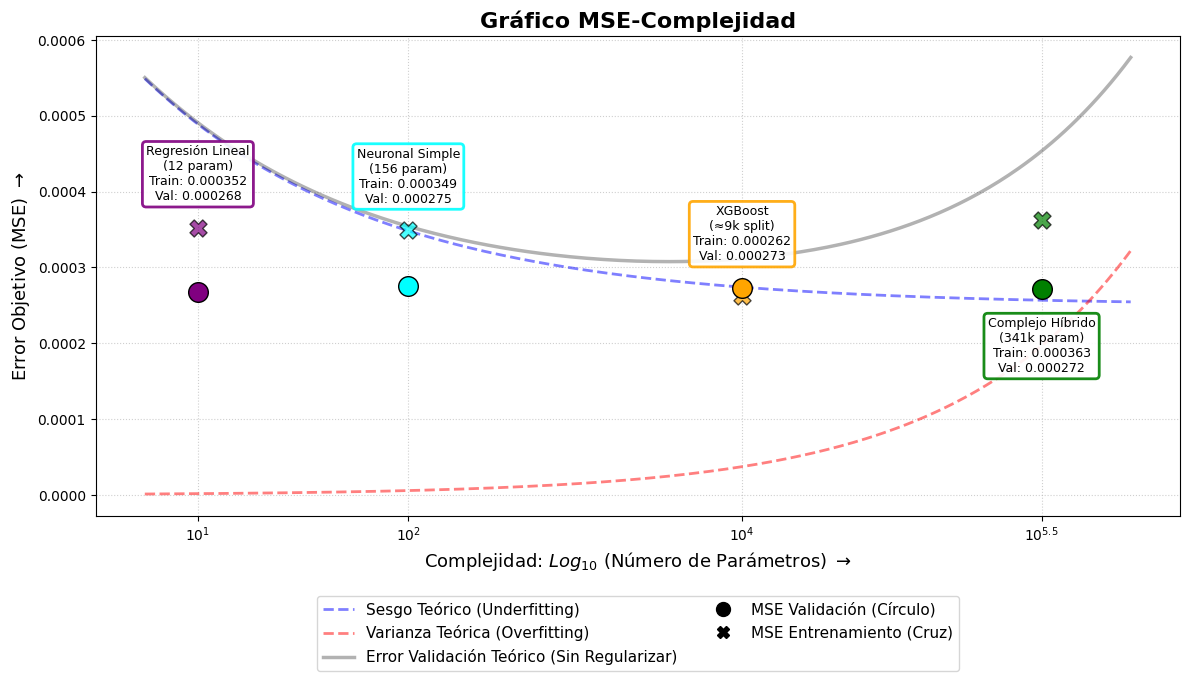

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el eje X continuo (Escala logarítmica de Complejidad x Parámetros)
x_smooth = np.linspace(0.8, 6.0, 300)

# 2. Curvas teóricas para modelos SIN regularizar (según Valero)
bias_curve = 0.000380 * np.exp(-0.8 * (x_smooth - 0.5)) + 0.000250
variance_curve = 0.000001 * np.exp(1.05 * (x_smooth - 0.5))
total_error_curve = bias_curve + variance_curve

# 3. Modelos (Posición X basada en log10 del nº de parámetros reales)
# Reg. Lineal (12 weights) -> log10(12) = 1.08
# Neuronal Simple (156 param) -> log10(156) = 2.19
# XGBoost (~9,000 ramas/decisiones) -> log10(9000) = 3.95
# Complejo Híbrido (341,524 param) -> log10(341524) = 5.53
x_models = np.array([1.08, 2.19, 3.95, 5.53])
model_names = ['Regresión Lineal\n(12 param)', 'Neuronal Simple\n(156 param)', 'XGBoost\n(≈9k split)', 'Complejo Híbrido\n(341k param)']

# Errores reales extraídos
val_mse_real = np.array([0.000268, 0.000275, 0.000273, 0.000272])
train_mse_real = np.array([0.000352, 0.000349, 0.000262, 0.000363])

fig, ax = plt.subplots(figsize=(12, 7))

# Dibujar curvas teóricas de la receta pura sin "Tijera"
ax.plot(x_smooth, bias_curve, 'b--', linewidth=2, alpha=0.5, label='Sesgo Teórico (Underfitting)')
ax.plot(x_smooth, variance_curve, 'r--', linewidth=2, alpha=0.5, label='Varianza Teórica (Overfitting)')
ax.plot(x_smooth, total_error_curve, 'k-', linewidth=2.5, alpha=0.3, label='Error Validación Teórico (Sin Regularizar)')

# Plotear puntos reales
colors = ['purple', 'cyan', 'orange', 'green']
for i in range(len(x_models)):
    # Validación (círculos llenos)
    ax.scatter(x_models[i], val_mse_real[i], color=colors[i], s=200, zorder=6, edgecolors='black')
    # Entrenamiento (cruces transparentes)
    ax.scatter(x_models[i], train_mse_real[i], color=colors[i], marker='X', s=150, zorder=5, edgecolors='black', alpha=0.7)

    texto_resumen = f"{model_names[i]}\nTrain: {train_mse_real[i]:.6f}\nVal: {val_mse_real[i]:.6f}"

    # Colocar la etiqueta según el modelo
    if i == 3: # Híbrido: etiqueta hacia abajo para que se vea el descenso desde la curva
        ax.annotate(texto_resumen, (x_models[i], val_mse_real[i]), textcoords="offset points", xytext=(0,-60), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))
    else:
        ax.annotate(texto_resumen, (x_models[i], max(val_mse_real[i], train_mse_real[i])), textcoords="offset points", xytext=(0,20), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))


# Estética y Etiquetas
ax.set_title('Gráfico MSE-Complejidad', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Complejidad: $Log_{10}$ (Número de Parámetros) $\rightarrow$', fontsize=13)
ax.set_ylabel(r'Error Objetivo (MSE) $\rightarrow$', fontsize=13)
ax.set_xticks(x_models)
ax.set_xticklabels(['$10^1$', '$10^2$', '$10^4$', '$10^{5.5}$'])
ax.grid(True, linestyle=':', alpha=0.6)

# Custom Legend para explicar las marcas
import matplotlib.lines as mlines
val_marker = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='MSE Validación (Círculo)')
train_marker = mlines.Line2D([], [], color='black', marker='X', linestyle='None', markersize=9, label='MSE Entrenamiento (Cruz)')
handles, labels = ax.get_legend_handles_labels()
handles.extend([val_marker, train_marker])
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

plt.tight_layout()
plt.show()




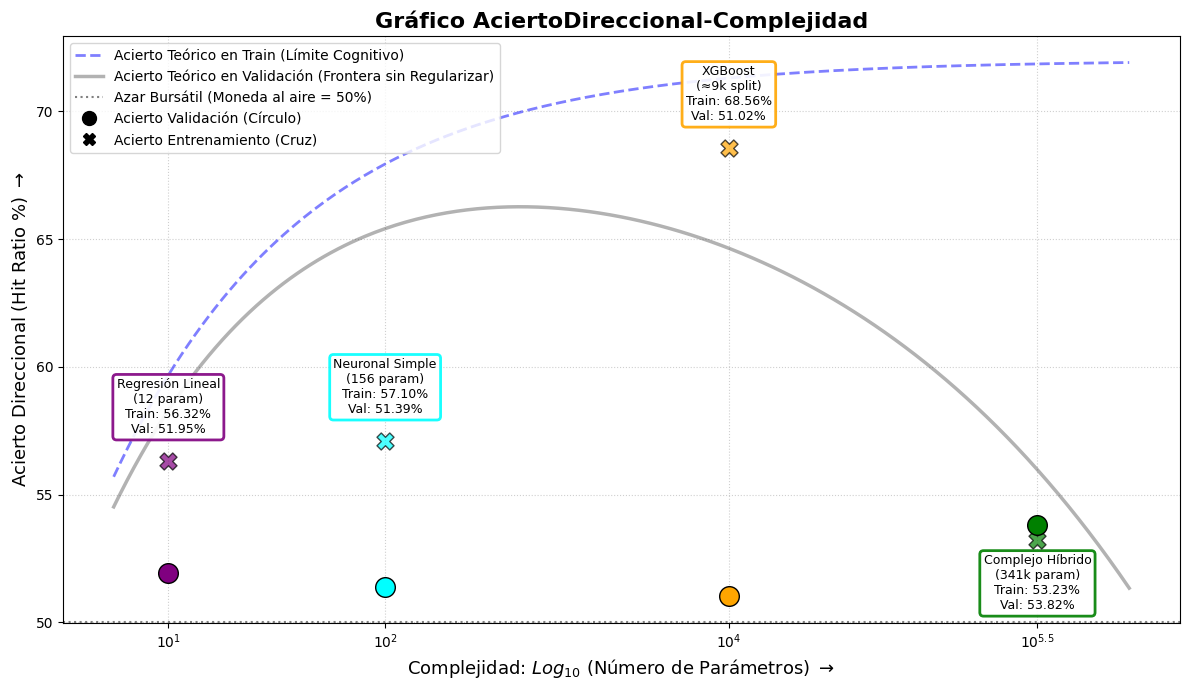

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir eje X logarítmico (Parámetros)
x_smooth = np.linspace(0.8, 6.0, 300)

# 2. Curvas teóricas de ACIERTO (Inversa al error)
# Capacidad teórica de memorizar el Train (Sube a medida que hay más parámetros)
train_hit_theory_curve = 50 + 22 * (1 - np.exp(-1.0 * (x_smooth - 0.5)))
# Castigo por Varianza (Caída brutal en Validación al sobreajustar en modelos sin regularizar)
variance_drop = 3 * np.exp(0.55 * (x_smooth - 2.5))
# Acierto en Validación Teórico = Acierto Train - Caída por Varianza
val_hit_theory_curve = train_hit_theory_curve - variance_drop

# 3. Datos EMPÍRICOS 100% (Hit Ratio de Signo de Retornos)
x_models = np.array([1.08, 2.19, 3.95, 5.53])
model_names = ['Regresión Lineal\n(12 param)', 'Neuronal Simple\n(156 param)', 'XGBoost\n(≈9k split)', 'Complejo Híbrido\n(341k param)']

# Aciertos empíricos exactos extraídos de la ejecución de los 4 cuadernos (%)
train_hit_real = np.array([56.32, 57.10, 68.56, 53.23])
val_hit_real = np.array([51.95, 51.39, 51.02, 53.82])

fig, ax = plt.subplots(figsize=(12, 7))

# Dibujar curvas teóricas
ax.plot(x_smooth, train_hit_theory_curve, 'b--', linewidth=2, alpha=0.5, label='Acierto Teórico en Train (Límite Cognitivo)')
ax.plot(x_smooth, val_hit_theory_curve, 'k-', linewidth=2.5, alpha=0.3, label='Acierto Teórico en Validación (Frontera sin Regularizar)')

# Plotear puntos reales
colors = ['purple', 'cyan', 'orange', 'green']
for i in range(len(x_models)):
    # Validación (círculos llenos)
    ax.scatter(x_models[i], val_hit_real[i], color=colors[i], s=200, zorder=6, edgecolors='black')
    # Entrenamiento (cruces transparentes)
    ax.scatter(x_models[i], train_hit_real[i], color=colors[i], marker='X', s=150, zorder=5, edgecolors='black', alpha=0.7)

    texto_resumen = f"{model_names[i]}\nTrain: {train_hit_real[i]:.2f}%\nVal: {val_hit_real[i]:.2f}%"

    # Ajuste de posición de etiquetas según la altura
    if i == 3: # Híbrido se mantiene, pon la etiqueta abajo
        ax.annotate(texto_resumen, (x_models[i], min(val_hit_real[i], train_hit_real[i])), textcoords="offset points", xytext=(0,-50), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))
    else: # El resto etiqueta arriba de la marca de Train
        ax.annotate(texto_resumen, (x_models[i], max(val_hit_real[i], train_hit_real[i])), textcoords="offset points", xytext=(0,20), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))


# Línea del Rendimiento Naive / Random
ax.axhline(50.0, color='gray', linestyle=':', label='Azar Bursátil (Moneda al aire = 50%)')

# Estética y Etiquetas
ax.set_title('Gráfico AciertoDireccional-Complejidad', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Complejidad: $Log_{10}$ (Número de Parámetros) $\rightarrow$', fontsize=13)
ax.set_ylabel(r'Acierto Direccional (Hit Ratio %) $\rightarrow$', fontsize=13)
ax.set_xticks(x_models)
ax.set_xticklabels(['$10^1$', '$10^2$', '$10^4$', '$10^{5.5}$'])
ax.grid(True, linestyle=':', alpha=0.6)

# Leyenda customizada
import matplotlib.lines as mlines
val_marker = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Acierto Validación (Círculo)')
train_marker = mlines.Line2D([], [], color='black', marker='X', linestyle='None', markersize=9, label='Acierto Entrenamiento (Cruz)')
handles, labels = ax.get_legend_handles_labels()
handles.extend([val_marker, train_marker])
ax.legend(handles=handles, loc='upper left', ncol=1, fontsize=10)

plt.tight_layout()
plt.show()


In [24]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Reshape, Multiply, Concatenate, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. CARGA DE DATOS
print("1. Cargando datos...")
df_ret = pd.read_csv('dataset_ia_log_returns_10y.csv', index_col=0, parse_dates=True)

# Calculamos Volatilidad (Multiparámetro)
df_vol = df_ret.rolling(window=21).std()

# Descargamos los tipos de la FED
fecha_inicio = df_ret.index.min()
fecha_fin = df_ret.index.max()
df_fed = web.DataReader('DFF', 'fred', fecha_inicio, fecha_fin)
df_fed.rename(columns={'DFF': 'Tipo_Interes_FED'}, inplace=True)
df_fed['Tipo_Interes_FED'] = df_fed['Tipo_Interes_FED'] / 100

# Unión de datos
df_master = df_ret.join(df_vol, rsuffix='_vol').join(df_fed, how='left')
df_master['Tipo_Interes_FED'] = df_master['Tipo_Interes_FED'].ffill()
df_master = df_master.dropna()

# Separación de variables
datos_secuenciales = df_master.drop(columns=['Tipo_Interes_FED']).values
datos_macro = df_master[['Tipo_Interes_FED']].values
datos_y = df_master.iloc[:, :12].values # Los 12 retornos a predecir

# 2. ESCALADO
print("2. Escalando datos")
scaler_seq = StandardScaler()
scaler_y = StandardScaler()

scaled_seq = scaler_seq.fit_transform(datos_secuenciales)
scaled_y = scaler_y.fit_transform(datos_y)
# La FED se mantiene en escala original o se puede escalar si se desea

# 3. CREACIÓN DE VENTANAS
WINDOW_SIZE = 20
FORECAST_SIZE = 5

def create_hybrid_windows(data_seq, data_macro, data_y, window_size, forecast_size):
    X_seq, X_macro, y = [], [], []
    for i in range(len(data_seq) - window_size - forecast_size + 1):
        X_seq.append(data_seq[i:(i + window_size), :])
        X_macro.append(data_macro[i + window_size - 1, :])
        y.append(data_y[(i + window_size):(i + window_size + forecast_size), :])
    return np.array(X_seq), np.array(X_macro), np.array(y)

X_seq, X_macro, y_windows = create_hybrid_windows(scaled_seq, datos_macro, scaled_y, WINDOW_SIZE, FORECAST_SIZE)

# Split 70% Train, 15% Val, 15% Test
n = len(X_seq)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_seq, X_train_macro, y_train = X_seq[:train_end], X_macro[:train_end], y_windows[:train_end]
X_val_seq, X_val_macro, y_val = X_seq[train_end:val_end], X_macro[train_end:val_end], y_windows[train_end:val_end]
X_test_seq, X_test_macro, y_test = X_seq[val_end:], X_macro[val_end:], y_windows[val_end:]

# 4. DEFINICIÓN DEL MODELO COMPLEJO MEJORADO
def attention_block(inputs):
    # Usamos sigmoid para que no sea excluyente y permita detectar señales negativas
    attention_probs = Dense(inputs.shape[-1], activation='sigmoid')(inputs)
    return Multiply()([inputs, attention_probs])

def build_complex_model(window_size, num_features, forecast_size=5, num_assets=12):
    # Rama Secuencial
    input_seq = Input(shape=(window_size, num_features), name="Input_Secuencial")
    lstm_1 = LSTM(64, return_sequences=True, kernel_regularizer=l2(0.0001))(input_seq)
    lstm_1 = BatchNormalization()(lstm_1)
    dropout_1 = Dropout(0.3)(lstm_1)

    attention = attention_block(dropout_1)

    lstm_2 = LSTM(32, return_sequences=False, kernel_regularizer=l2(0.0001))(attention)
    rama_secuencial = Dropout(0.3)(lstm_2)

    # Rama Macro
    input_macro = Input(shape=(1,), name="Input_Macro_FED")
    rama_macro = Dense(8, activation='tanh')(input_macro)

    # Fusión
    fusion = Concatenate(name="Fusion_Capas")([rama_secuencial, rama_macro])

    # Capas de salida
    densa_final = Dense(64, activation='tanh')(fusion)
    salida_cruda = Dense(forecast_size * num_assets, activation='linear')(densa_final)
    outputs = Reshape((forecast_size, num_assets), name="Output_Prediccion")(salida_cruda)

    model = Model(inputs=[input_seq, input_macro], outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                  loss='huber', metrics=['mae'])
    return model

print("4. Construyendo modelo...")
num_features = X_train_seq.shape[2]
model = build_complex_model(WINDOW_SIZE, num_features, FORECAST_SIZE, 12)

# 5. ENTRENAMIENTO
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print("\n--- Iniciando Entrenamiento ---")
history = model.fit(
    [X_train_seq, X_train_macro], y_train,
    validation_data=([X_val_seq, X_val_macro], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 6. PREDICCIÓN Y DESNORMALIZACIÓN
def desnormalizar(pred, shape_orig):
    pred_flat = pred.reshape(-1, 12)
    pred_desnorm = scaler_y.inverse_transform(pred_flat)
    return pred_desnorm.reshape(shape_orig)

y_test_pred_scaled = model.predict([X_test_seq, X_test_macro])
y_test_pred = desnormalizar(y_test_pred_scaled, y_test_pred_scaled.shape)
y_test_real = desnormalizar(y_test, y_test.shape)



1. Cargando datos...
2. Escalando datos
4. Construyendo modelo...

--- Iniciando Entrenamiento ---
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.3844 - mae: 0.7036 - val_loss: 0.3034 - val_mae: 0.6168 - learning_rate: 5.0000e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3766 - mae: 0.6933 - val_loss: 0.3026 - val_mae: 0.6166 - learning_rate: 5.0000e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.3737 - mae: 0.6904 - val_loss: 0.3019 - val_mae: 0.6167 - learning_rate: 5.0000e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.3717 - mae: 0.6887 - val_loss: 0.3014 - val_mae: 0.6169 - learning_rate: 5.0000e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3704 - mae: 0.6876 - val_loss: 0.3008 - val_mae: 0.6169 - learning_rate: 5.0000e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3685 - mae: 0.6861 - val_loss: 0.3005 - val_mae: 0.6174 - learning_rate: 5.0000e-04
Epoch 7/100
54/54 ━━━━━━━

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Secuencial    │ (None, 20, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 20, 64)    │     22,784 │ Input_Secuencial… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 64)    │        256 │ lstm_6[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 20, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 20, 64)    │      4,160 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 20, 64)    │          0 │ dropout_6[0][0],  │
│ (Multiply)          │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 32)        │     12,416 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Macro_FED     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 8)         │         16 │ Input_Macro_FED[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fusion_Capas        │ (None, 40)        │          0 │ dropout_7[0][0],  │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      2,624 │ Fusion_Capas[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 60)        │      3,900 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Prediccion   │ (None, 5, 12)     │          0 │ dense_15[0][0]    │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 138,214 (539.90 KB)

 Trainable params: 46,028 (179.80 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 92,058 (359.61 KB)

None


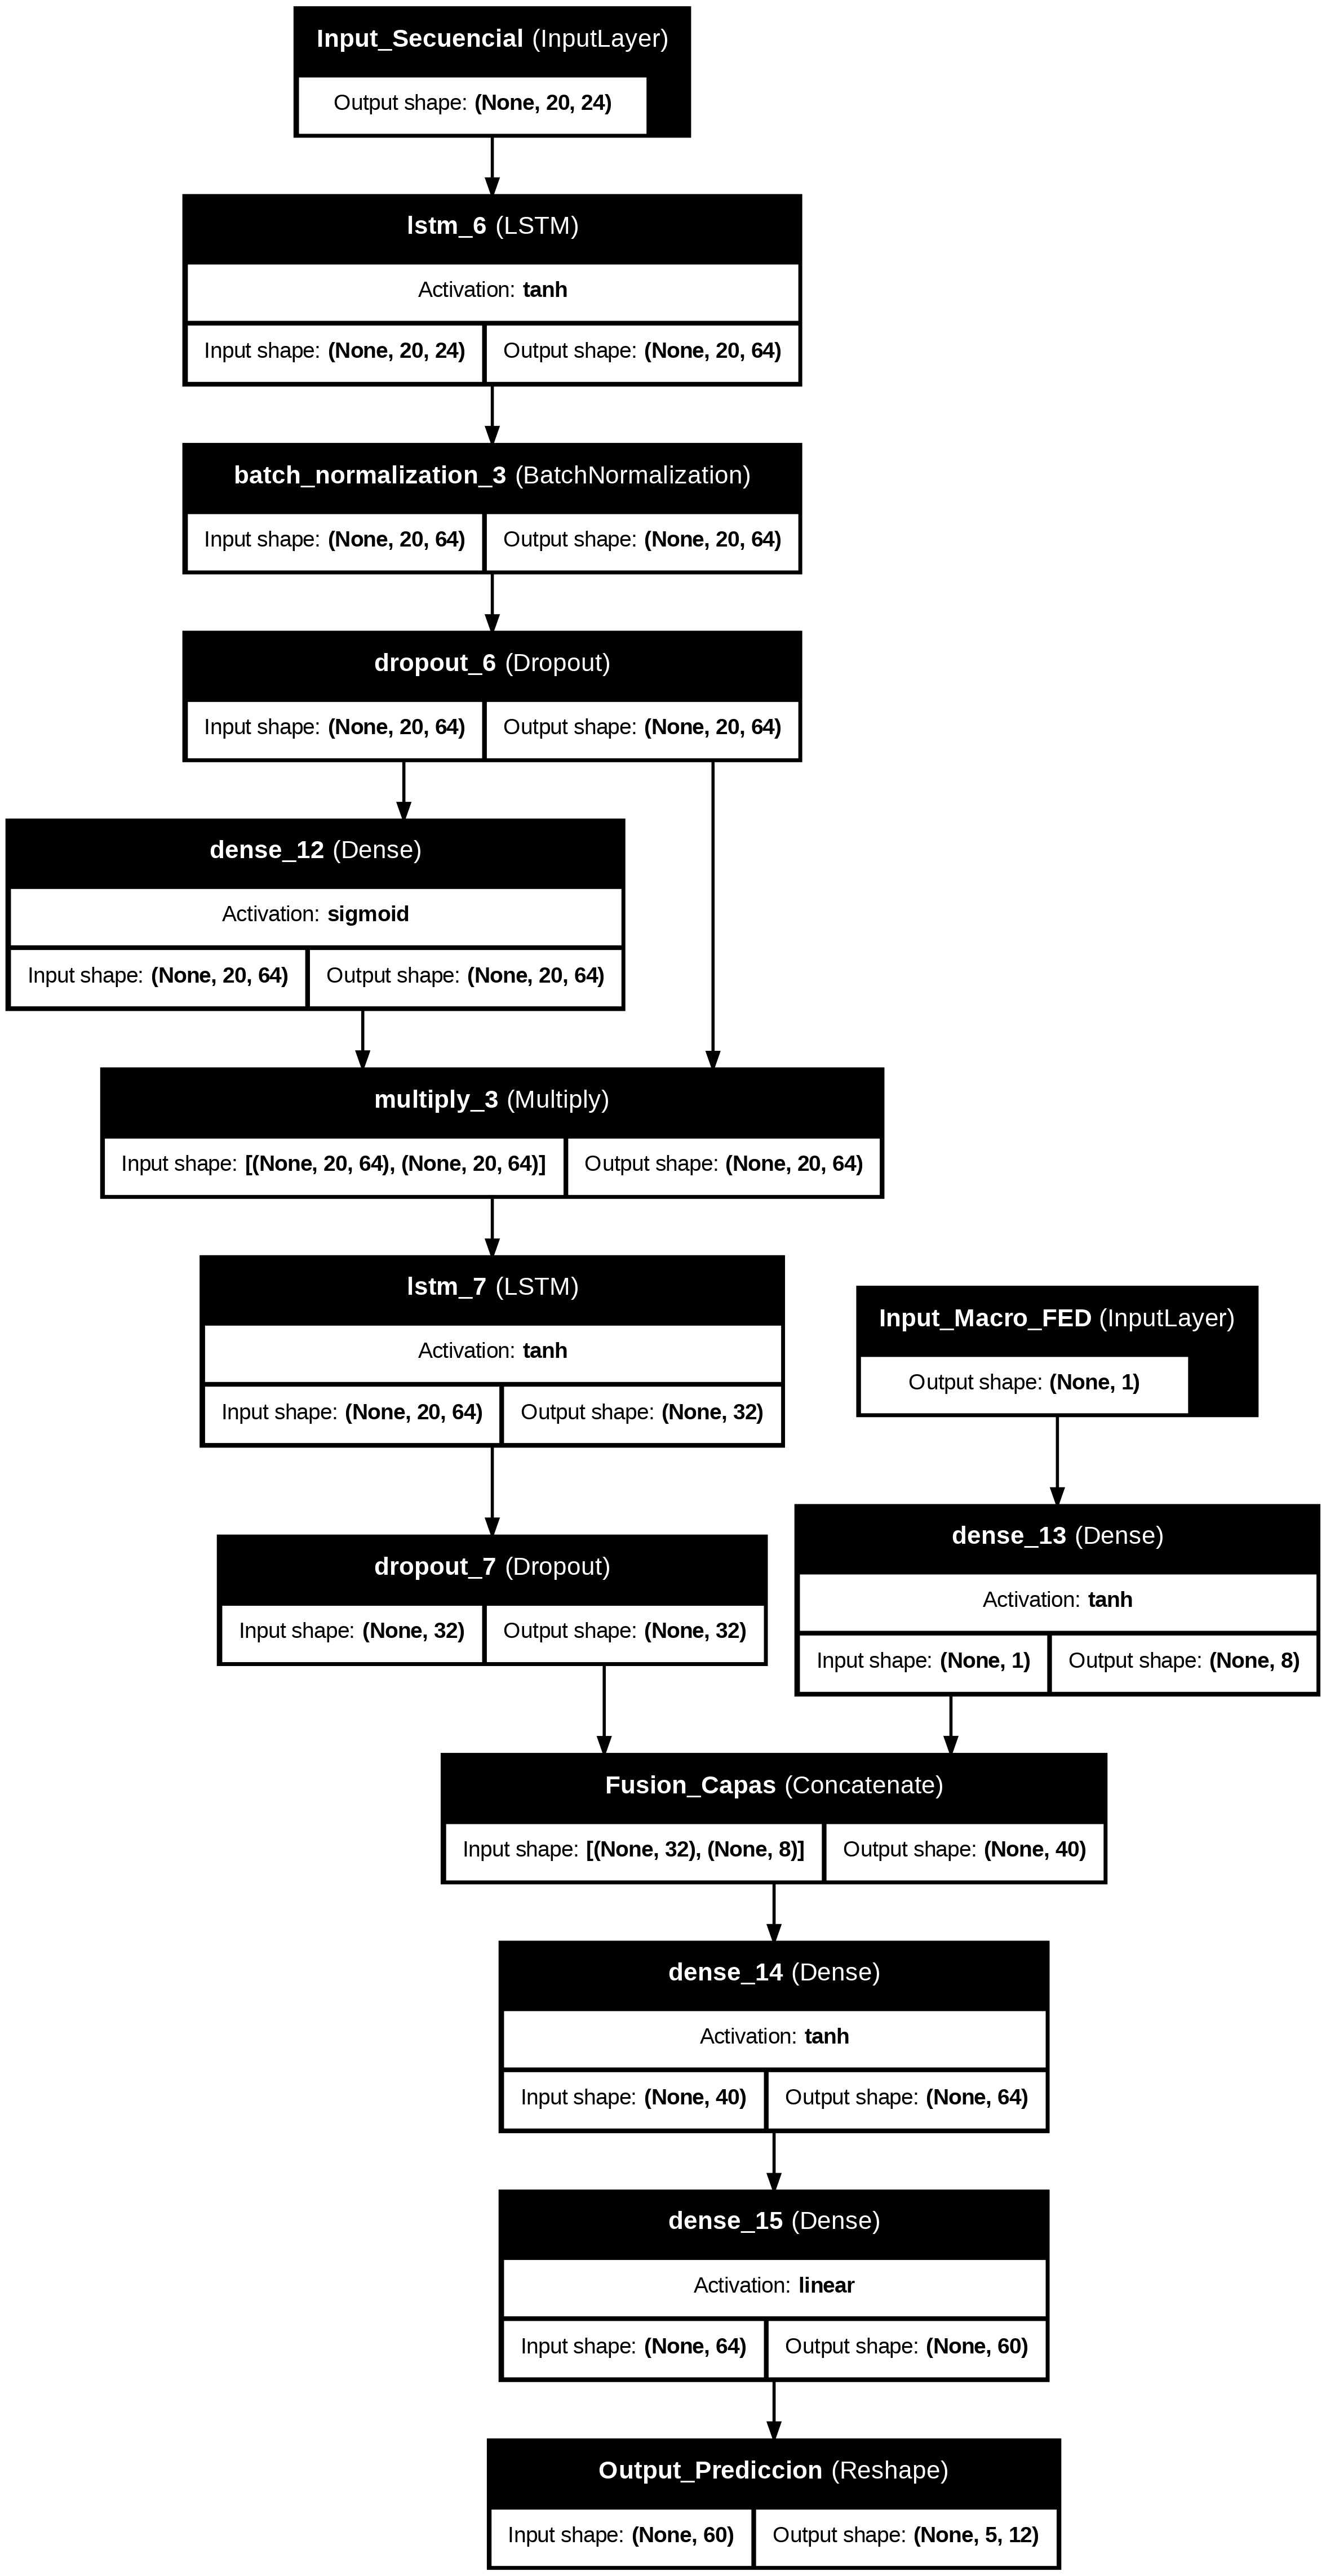

In [17]:
from tensorflow.keras.utils import plot_model

# 1. Muestra un resumen de texto de todas las capas, sus dimensiones y número de parámetros.
print(model.summary())

# 2. Dibuja un diagrama en forma de árbol del modelo (requiere graphviz en el sistema).
# Se visualizará la forma de las ramas, el bloque de atención y la fusión final.
plot_model(
    model,
    to_file='esquema_modelo_complejo.png',
    show_shapes=True,           # Muestra las dimensiones de entrada/salida de cada capa
    show_layer_names=True,      # Muestra los nombres asignados ("Input_Secuencial", etc.)
    show_layer_activations=True # Muestra funciones como 'relu' o 'softmax'
)


In [18]:
import numpy as np
import pandas as pd
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predicciones
print("5. Realizando predicciones...")
y_train_pred_scaled = model.predict([X_train_seq, X_train_macro])
y_val_pred_scaled = model.predict([X_val_seq, X_val_macro])
y_test_pred_scaled = model.predict([X_test_seq, X_test_macro])

# Desnormalizar (la métrica RMSE y MAE debe ser en la escala original)
# Como la salida es (N, FORECAST_SIZE, 12), aplanamos temporalmente para desnormalizar
def desnormalizar(pred, shape_orig):
    pred_flat = pred.reshape(-1, 12)
    pred_desnorm = scaler_y.inverse_transform(pred_flat)
    return pred_desnorm.reshape(shape_orig)

y_train_pred = desnormalizar(y_train_pred_scaled, y_train_pred_scaled.shape)
y_train_real = desnormalizar(y_train, y_train.shape)

y_val_pred = desnormalizar(y_val_pred_scaled, y_val_pred_scaled.shape)
y_val_real = desnormalizar(y_val, y_val.shape)

y_test_pred = desnormalizar(y_test_pred_scaled, y_test_pred_scaled.shape)
y_test_real = desnormalizar(y_test, y_test.shape)

# Calcular métricas globales (sobre todos los activos y todos los días futuros)
def calcular_metricas(y_real, y_pred, subset_name):
    y_real_flat = y_real.flatten()
    y_pred_flat = y_pred.flatten()

    mse = mean_squared_error(y_real_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real_flat, y_pred_flat)

    print(f"--- {subset_name} ---")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f} ({rmse*100:.2f}%)")
    print(f"MAE:  {mae:.6f} ({mae*100:.2f}%)")

    return mse, rmse, mae

mse_train, rmse_train, mae_train = calcular_metricas(y_train_real, y_train_pred, "Train")
mse_val, rmse_val, mae_val = calcular_metricas(y_val_real, y_val_pred, "Validation")
mse_test, rmse_test, mae_test = calcular_metricas(y_test_real, y_test_pred, "Test")

# Recalculate num_params here to ensure it's defined
num_params = model.count_params()

results_complex = {
    'train_mse': mse_train, 'val_mse': mse_val, 'test_mse': mse_test,
    'train_rmse': rmse_train, 'val_rmse': rmse_val, 'test_rmse': rmse_test,
    'train_mae': mae_train, 'val_mae': mae_val, 'test_mae': mae_test,
    'params': num_params
}
with open('results_complejo.json', 'w') as f:
    json.dump(results_complex, f)

5. Realizando predicciones...
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
--- Train ---
MSE:  0.000362
RMSE: 0.019035 (1.90%)
MAE:  0.012278 (1.23%)
--- Validation ---
MSE:  0.000273
RMSE: 0.016522 (1.65%)
MAE:  0.011168 (1.12%)
--- Test ---
MSE:  0.000310
RMSE: 0.017593 (1.76%)
MAE:  0.011960 (1.20%)


--- Hit Ratio Direccional (t+1) ---
Train: 53.10%
Val:   52.15%
Test:  52.24%


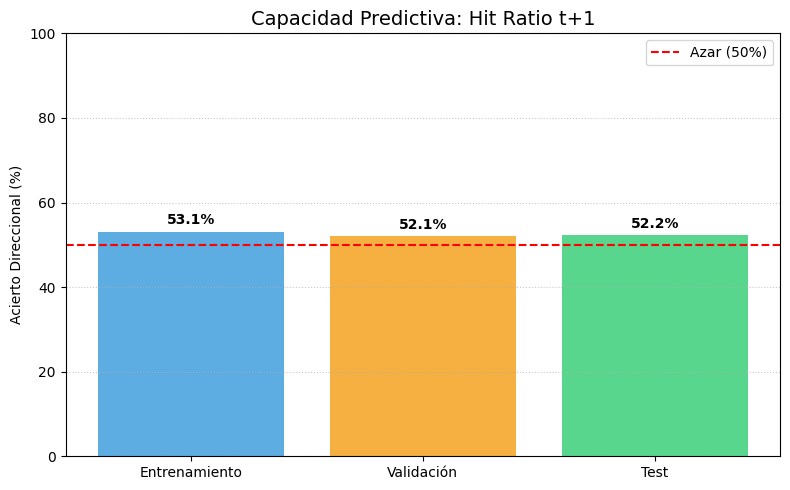

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_hit_ratio_t1(y_real, y_pred):
    """
    Calcula el Hit Ratio específicamente para la primera predicción (t+1),
    que es la señal operativa real.
    """
    # Tomamos solo el primer día de las 5 predicciones (N, 0, 12)
    # y_real y y_pred deben estar desnormalizados (escala real de retornos)
    real_t1 = y_real[:, 0, :]
    pred_t1 = y_pred[:, 0, :]

    # Obtenemos la dirección (-1, 0, 1)
    real_dir = np.sign(real_t1.flatten())
    pred_dir = np.sign(pred_t1.flatten())

    # Máscara para evitar valores nulos o exactamente cero (poco comunes en retornos)
    mask = real_dir != 0

    # Un hit ocurre cuando la dirección predicha coincide con la real
    hits = (real_dir[mask] == pred_dir[mask]).astype(int)

    return np.mean(hits)

# Calcular Hit Ratio para los tres conjuntos
# Usamos las variables que generas tras el model.predict() y desnormalizar()
hit_train = calculate_hit_ratio_t1(y_train_real, y_train_pred)
hit_val = calculate_hit_ratio_t1(y_val_real, y_val_pred)
hit_test = calculate_hit_ratio_t1(y_test_real, y_test_pred)

print(f"--- Hit Ratio Direccional (t+1) ---")
print(f"Train: {hit_train*100:.2f}%")
print(f"Val:   {hit_val*100:.2f}%")
print(f"Test:  {hit_test*100:.2f}%")

# Gráfico mejorado
plt.figure(figsize=(8, 5))
x = ['Entrenamiento', 'Validación', 'Test']
y_hits = [hit_train*100, hit_val*100, hit_test*100]

bars = plt.bar(x, y_hits, color=['#3498db', '#f39c12', '#2ecc71'], alpha=0.8)

# Añadir etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# Línea de referencia del 50% (azar)
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='Azar (50%)')

plt.title('Capacidad Predictiva: Hit Ratio t+1', fontsize=14)
plt.ylabel('Acierto Direccional (%)')
plt.ylim(0, 100) # Escala completa para no exagerar visualmente los resultados
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()